In [61]:
import torch
import torch_geometric.transforms as T
from torch.utils.data import random_split
from torch_geometric.datasets import MNISTSuperpixels

## Define sparsification and noise addtiontion as per GSAT paper

In [62]:
class SparsifyGraph(object):

    def __init__(self, threshold=0.1):
        self.threshold = threshold
    
    def __call__(self, data):

        row, col = data.edge_index

        pos = data.pos
        pos_min = pos.min(dim=0).values
        pos_max = pos.max(dim=0).values
        denom = (pos_max - pos_min).clamp(min=1e-8)
        pos_norm = (pos - pos_min) / denom

        dist = torch.norm(pos_norm[row] - pos_norm[col], p=2, dim=-1)

        mask = dist < self.threshold

        data.edge_index = data.edge_index[:, mask]

        if data.edge_attr is not None:
            data.edge_attr = data.edge_attr[mask]

        return data
    

class AddGroundTruthMark(object):

    def __call__(self, data):

        data.node_mask = (data.x[:, 0] > 0).float()

        return data
    
pre_transform = T.Compose([SparsifyGraph(threshold=0.1), AddGroundTruthMark()])

## Load the dataset and apply sparsification

In [63]:

train_val_dataset = MNISTSuperpixels(root='data/MNIST', train=True, transform=pre_transform)
test_dataset = MNISTSuperpixels(root='data/MNIST', train=False, transform=pre_transform)

Extracting data/MNIST/raw/MNISTSuperpixels.zip
Processing...
Done!


In [64]:
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

all_labels = [data.y.item() for data in train_val_dataset]

train_val_indices, _ = train_test_split(
    range(len(train_val_dataset)),
    train_size=25000,
    stratify=all_labels,
    random_state=42
)

subset_labels = [all_labels[i] for i in train_val_indices]

train_indices, val_indices = train_test_split(
    train_val_indices,
    train_size=20000,
    stratify=subset_labels,
    random_state=42
)

train_dataset = Subset(train_val_dataset, train_indices)
val_dataset = Subset(train_val_dataset, val_indices)

train_set = set(train_indices)
val_set = set(val_indices)
assert len(train_set & val_set) == 0, "Train/Val overlap found."
assert len(train_set) + len(val_set) == len(set(train_val_indices)), "Split coverage mismatch."

train_hist = Counter(all_labels[i] for i in train_indices)
val_hist = Counter(all_labels[i] for i in val_indices)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Classes in train: {len(train_hist)}, classes in val: {len(val_hist)}")
print("Train class count range:", min(train_hist.values()), "to", max(train_hist.values()))
print("Val class count range:", min(val_hist.values()), "to", max(val_hist.values()))
print("Sparsification-only pipeline active (no Gaussian noise).")

Train dataset size: 20000
Validation dataset size: 5000
Test dataset size: 10000
Classes in train: 10, classes in val: 10
Train class count range: 1807 to 2247
Val class count range: 452 to 562
Sparsification-only pipeline active (no Gaussian noise).


In [65]:
from collections import Counter
from torch.utils.data import Subset

# 1. Extract all labels from the original 10,000 graph test dataset
test_labels = [data.y.item() for data in test_dataset]

# 2. Collect exactly 100 indices per class
balanced_test_indices = []
class_counts = Counter()
samples_per_class = 100

for idx, label in enumerate(test_labels):
    if class_counts[label] < samples_per_class:
        balanced_test_indices.append(idx)
        class_counts[label] += 1
        
    # Optimization: Stop iterating early if we have 100 of each of the 10 classes
    if sum(class_counts.values()) == 1000:
        break

# 3. Create the new balanced test subset
balanced_test_dataset = Subset(test_dataset, balanced_test_indices)

# 4. Verify the distribution
balanced_test_labels = [test_labels[i] for i in balanced_test_indices]
print(f"New test dataset size: {len(balanced_test_dataset)}")
print(f"New test class distribution: {Counter(balanced_test_labels)}")

New test dataset size: 1000
New test class distribution: Counter({7: 100, 2: 100, 1: 100, 0: 100, 4: 100, 9: 100, 5: 100, 6: 100, 3: 100, 8: 100})


## Visualize and save data

Visualizing one sample from each class in the training dataset:


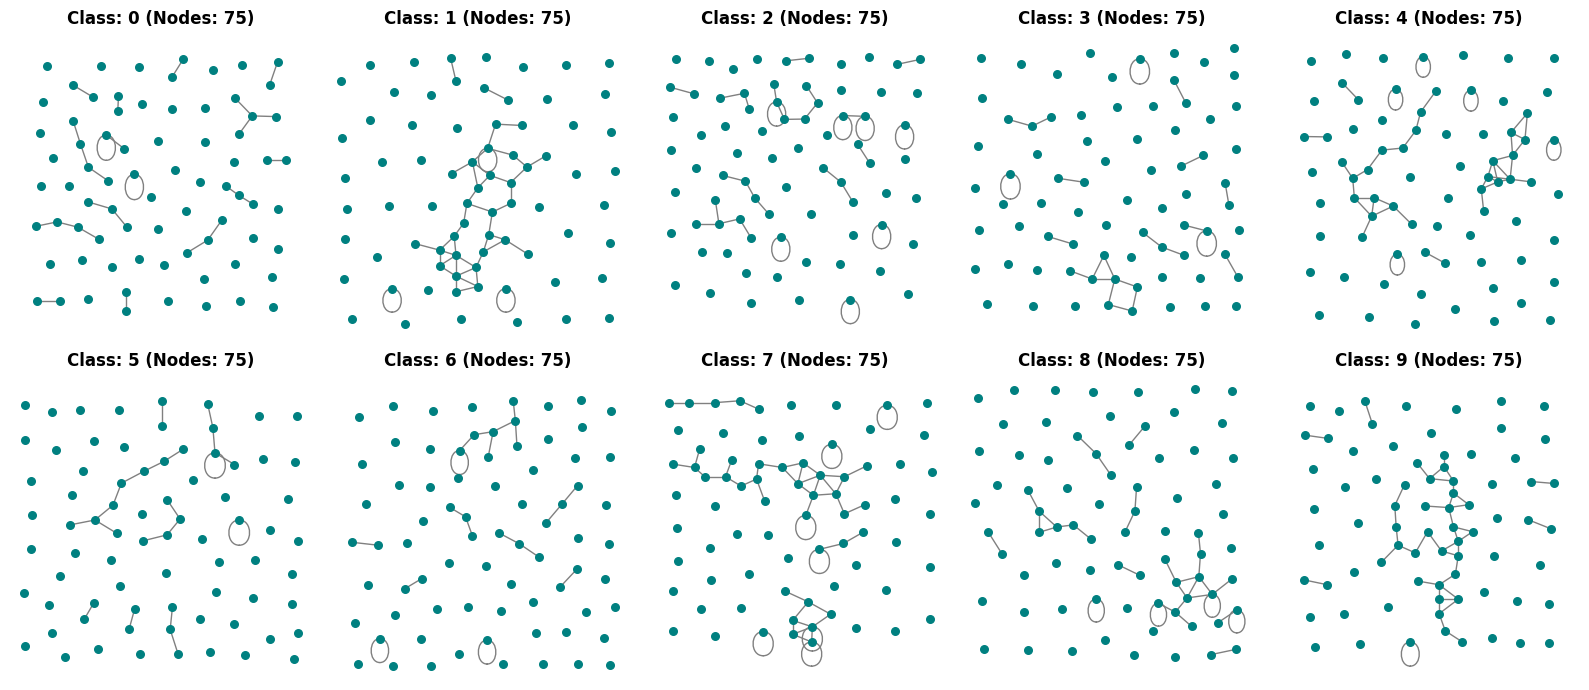

In [66]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

class_samples = {}

for i in range(len(train_dataset)):
    data = train_dataset[i]
    label = data.y.item()
    if label not in class_samples:
        class_samples[label] = data
    if len(class_samples) == 10:
        break

print("Visualizing one sample from each class in the training dataset:")

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for class_idx, ax in zip(sorted(class_samples.keys()), axes):
    data = class_samples[class_idx]
    G = to_networkx(data, to_undirected=True)
    pos = {j: data.pos[j].numpy() for j in range(data.num_nodes)}
    nx.draw(
        G,
        pos,
        ax=ax,
        node_size=30,
        node_color='teal',
        edge_color='gray',
        with_labels=False
    )
    ax.invert_yaxis()
    ax.set_title(f"Class: {class_idx} (Nodes: {data.num_nodes})", fontweight='bold')

for ax in axes[len(class_samples):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

/var/folders/7z/v5vlp84n7pl7lqlv_7xw5_z40000gn/T/ipykernel_16012/615990268.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


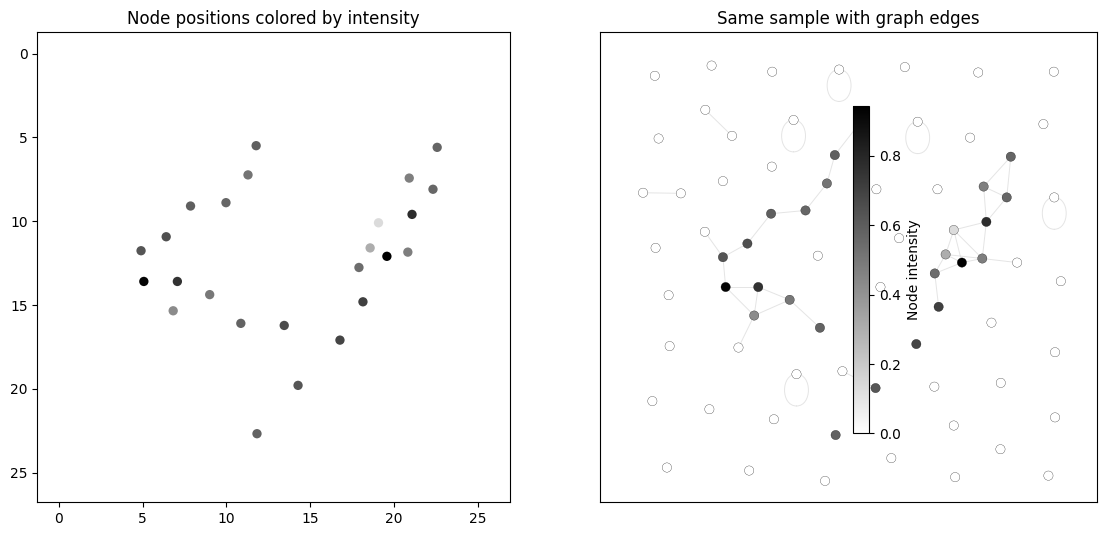

Label: 4
Nodes: 75, Edges: 75


In [67]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

sample_idx = 0
data = train_dataset[sample_idx]

pos = data.pos.cpu().numpy()
intensity = data.x[:, 0].cpu().numpy() if data.x.dim() > 1 else data.x.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    pos[:, 0],
    pos[:, 1],
    c=intensity,
    cmap='gray_r',
    s=45,
    edgecolors='none'
 )
axes[0].invert_yaxis()
axes[0].set_title('Node positions colored by intensity')
axes[0].set_aspect('equal')

graph = to_networkx(data, to_undirected=True)
pos_dict = {i: pos[i] for i in range(data.num_nodes)}
nx.draw_networkx_edges(graph, pos_dict, ax=axes[1], edge_color='lightgray', alpha=0.6, width=0.7)
scatter = axes[1].scatter(
    pos[:, 0],
    pos[:, 1],
    c=intensity,
    cmap='gray_r',
    s=45,
    edgecolors='black',
    linewidths=0.2
 )
axes[1].invert_yaxis()
axes[1].set_title('Same sample with graph edges')
axes[1].set_aspect('equal')

fig.colorbar(scatter, ax=axes, shrink=0.85, label='Node intensity')
plt.tight_layout()
plt.show()

print(f'Label: {int(data.y.item())}')
print(f'Nodes: {data.num_nodes}, Edges: {data.edge_index.size(1)}')

Plotting the graphs (Image-style)...


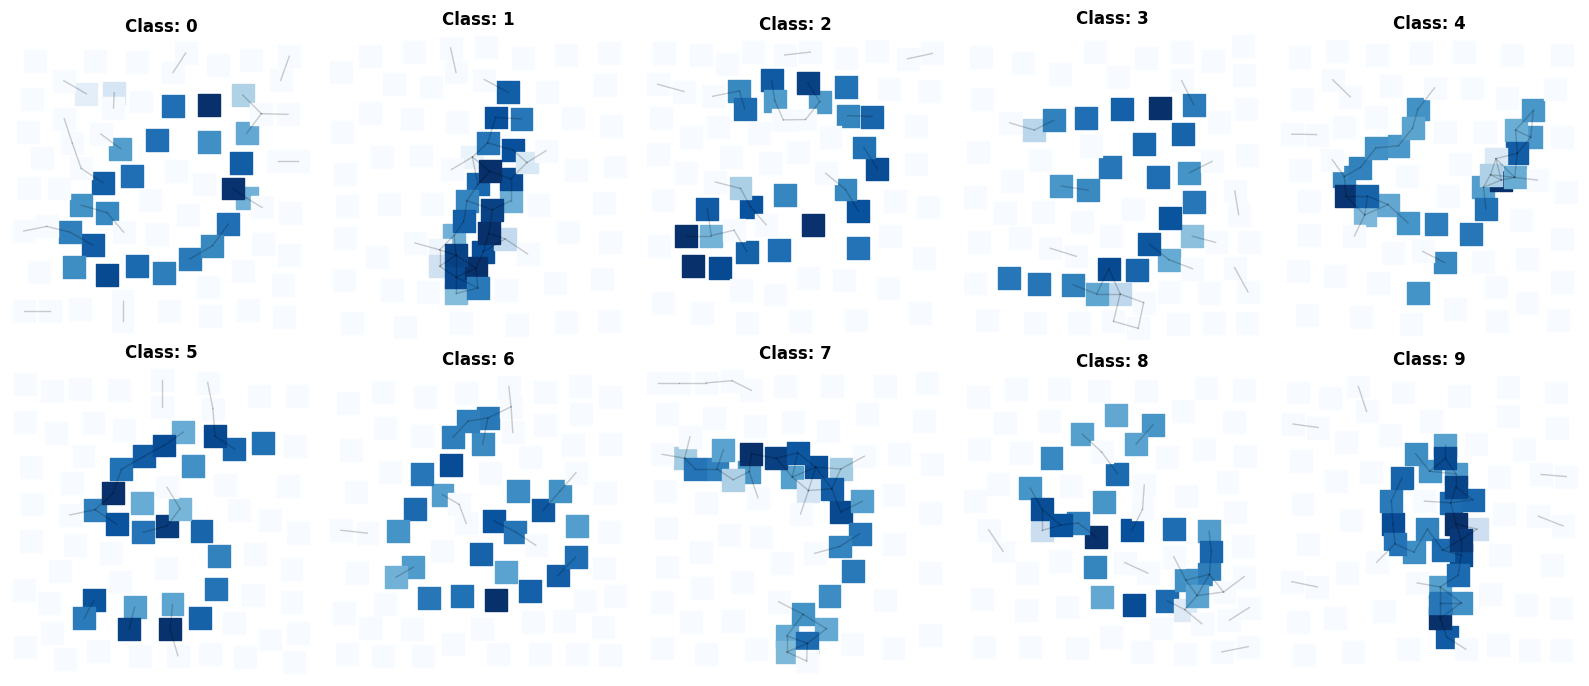

In [68]:
import matplotlib.pyplot as plt
import networkx as nx

print("Plotting the graphs (Image-style)...")
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for class_idx, ax in zip(sorted(class_samples.keys()), axes.flatten()):
    graph_data = class_samples[class_idx]
    
    # 1. Get coordinates and pixel intensities
    x_coords = graph_data.pos[:, 0].numpy()
    y_coords = graph_data.pos[:, 1].numpy()
    
    # The first feature column in data.x is the pixel intensity
    intensities = graph_data.x[:, 0].numpy() 
    
    # 2. Draw nodes as large squares instead of dots
    # 's' is marker size, tweak this number to make the "pixels" touch
    ax.scatter(x_coords, y_coords, 
               c=intensities, cmap='Blues',  # Use 'gray' or 'Blues'
               marker='s', s=250)            # 's' specifies a square marker
    
    # Optional: If you still want to see the graph structure underneath, 
    # you can lightly draw the edges on top.
    import torch
    row, col = graph_data.edge_index
    for i in range(graph_data.num_edges):
        start = graph_data.pos[row[i]].numpy()
        end = graph_data.pos[col[i]].numpy()
        ax.plot([start[0], end[0]], [start[1], end[1]], color='black', alpha=0.1, linewidth=1)
    
    # Format the plot
    ax.invert_yaxis() # Keep digits upright
    ax.set_aspect('equal') # Keep the proportions square
    ax.axis('off') # Hide the grid and axes for a clean image look
    ax.set_title(f"Class: {class_idx}", fontweight='bold')

plt.tight_layout()
plt.show()

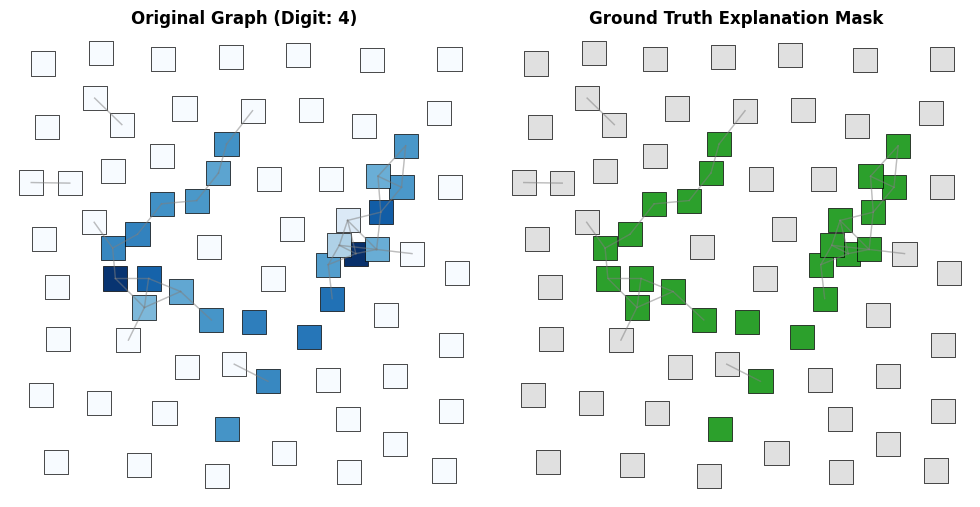

In [69]:
import matplotlib.pyplot as plt

def plot_graph_and_mask(graph_data):
    """Plots a sparsified superpixel graph with its ground-truth node mask."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    x_coords = graph_data.pos[:, 0].numpy()
    y_coords = graph_data.pos[:, 1].numpy()
    row, col = graph_data.edge_index

    intensities = graph_data.x[:, 0].numpy()
    for i in range(graph_data.num_edges):
        start = graph_data.pos[row[i]].numpy()
        end = graph_data.pos[col[i]].numpy()
        ax1.plot([start[0], end[0]], [start[1], end[1]], color='gray', alpha=0.3, linewidth=1)

    ax1.scatter(
        x_coords, y_coords, c=intensities, cmap='Blues',
        marker='s', s=300, edgecolor='black', linewidth=0.5
    )
    ax1.invert_yaxis()
    ax1.set_aspect('equal')
    ax1.axis('off')
    ax1.set_title(f"Original Graph (Digit: {graph_data.y.item()})", fontweight='bold')

    gt_mask = graph_data.node_mask.numpy()
    for i in range(graph_data.num_edges):
        start = graph_data.pos[row[i]].numpy()
        end = graph_data.pos[col[i]].numpy()
        ax2.plot([start[0], end[0]], [start[1], end[1]], color='gray', alpha=0.3, linewidth=1)

    cmap_binary = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c'])
    ax2.scatter(
        x_coords, y_coords, c=gt_mask, cmap=cmap_binary,
        marker='s', s=300, edgecolor='black', linewidth=0.5
    )
    ax2.invert_yaxis()
    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.set_title("Ground Truth Explanation Mask", fontweight='bold')

    plt.tight_layout()
    plt.show()

# Reuse already loaded/sparsified data (no new dataset download)
sample_graph = train_dataset[0]
plot_graph_and_mask(sample_graph)

In [74]:
from pathlib import Path

def _materialize_split(split_dataset):
    return [split_dataset[i].clone() for i in range(len(split_dataset))]

export_dir = Path("data/MNIST/sparsified_pt_splits")
export_dir.mkdir(parents=True, exist_ok=True)

train_pt = export_dir / "train_sparsified.pt"
val_pt = export_dir / "val_sparsified.pt"
test_pt = export_dir / "test_sparsified.pt"
meta_pt = export_dir / "split_metadata.pt"

train_graphs = _materialize_split(train_dataset)
torch.save(train_graphs, train_pt)
del train_graphs

val_graphs = _materialize_split(val_dataset)
torch.save(val_graphs, val_pt)
del val_graphs

test_graphs = _materialize_split(balanced_test_dataset)
torch.save(test_graphs, test_pt)
del test_graphs

metadata = {
    "source": "MNISTSuperpixels",
    "sparsification": {
        "threshold": 0.1,
        "distance_space": "per-graph min-max normalized coordinates",
        "gaussian_noise": None
    },
    "split": {
        "train_size": len(train_dataset),
        "val_size": len(val_dataset),
        "test_size": len(balanced_test_dataset),
        "train_indices": list(train_indices),
        "val_indices": list(val_indices),
        "train_val_source_size": len(train_val_dataset),
        "split_seed": 42
    },
    "files": {
        "train": str(train_pt),
        "val": str(val_pt),
        "test": str(test_pt)
    }
}
torch.save(metadata, meta_pt)

reloaded_train = torch.load(train_pt, map_location="cpu", weights_only=False)
reloaded_val = torch.load(val_pt, map_location="cpu", weights_only=False)
reloaded_test = torch.load(test_pt, map_location="cpu", weights_only=False)
reloaded_meta = torch.load(meta_pt, map_location="cpu", weights_only=False)

assert len(reloaded_train) == len(train_dataset), "Train .pt size mismatch."
assert len(reloaded_val) == len(val_dataset), "Val .pt size mismatch."
assert len(reloaded_test) == len(balanced_test_dataset), "Test .pt size mismatch."
assert reloaded_meta["sparsification"]["gaussian_noise"] is None, "Gaussian noise flag should be None."

print("Saved sparsified dataset splits successfully:")
print(f"- {train_pt}")
print(f"- {val_pt}")
print(f"- {test_pt}")
print(f"- {meta_pt}")
print("Reload checks passed. Splits are reusable in other code.")

Saved sparsified dataset splits successfully:
- data/MNIST/sparsified_pt_splits/train_sparsified.pt
- data/MNIST/sparsified_pt_splits/val_sparsified.pt
- data/MNIST/sparsified_pt_splits/test_sparsified.pt
- data/MNIST/sparsified_pt_splits/split_metadata.pt
Reload checks passed. Splits are reusable in other code.


## Data Statistics

In [72]:
len_train = len(train_dataset)
len_val = len(val_dataset)
len_test = len(test_dataset)
print(f"Train dataset size: {len_train}")
print(f"Validation dataset size: {len_val}")
print(f"Test dataset size: {len_test}")

Train dataset size: 20000
Validation dataset size: 5000
Test dataset size: 10000


In [12]:
import torch
sample = torch.load("data/MNIST/sparsified_pt_splits/train_sparsified.pt", weights_only=False)[0]
print(hasattr(sample, "node_mask"), sample.node_mask.shape if hasattr(sample, "node_mask") else None)

True torch.Size([75])
